In [1]:
# Upload files
from google.colab import files
uploaded = files.upload()

Saving cleaned_comments.csv to cleaned_comments.csv


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utility modules
import re
import ast
from collections import Counter
from itertools import combinations, cycle

In [3]:
# Load data
df = pd.read_csv('cleaned_comments.csv')

# Inspect first few rows
print(df.head())

# If tokens are stored as strings like "['a','b']", convert to Python lists
if isinstance(df["cleaned_tokens"].iloc[0], str):
    df["cleaned_tokens"] = df["cleaned_tokens"].apply(ast.literal_eval)

# Quick sanity checks
print("Rows:", len(df))
print("Sample tokens:", df["cleaned_tokens"].iloc[0][:10])

                        username             timestamp  likes  \
0                 heidierwin3546  2025-10-19T22:03:01Z      0   
1             magdalenaojeda3315  2025-10-18T08:30:23Z      0   
2              anadikulkarni5039  2025-10-14T11:22:03Z      0   
3                   F8ferrari888  2025-10-11T00:32:33Z      0   
4  FlexTransportationServicesLLC  2025-10-09T21:31:10Z      0   

                                        comment_text  \
0  This was good, but probably needs to be update...   
1                                   This is amazing!   
2    Ngl this was just a giant Twilio advertisement.   
3  Are you Mr Beasts&#39; father? lol. Why do you...   
4  I would like to reach out to you. I have been ...   

                                      cleaned_tokens  tok_len  char_len  \
0  ['good', 'probably', 'need', 'updated', 'examp...       10       107   
1                                        ['amazing']        1        16   
2        ['ngl', 'giant', 'twilio', 'advertisem

In [4]:
# Create Chunks
chunks = np.array_split(df, 5)
for i, ch in enumerate(chunks, 1):
    print(f"Chunk {i}: {len(ch)} rows")

Chunk 1: 193 rows
Chunk 2: 193 rows
Chunk 3: 193 rows
Chunk 4: 192 rows
Chunk 5: 192 rows


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [5]:
# Helper function for Barplot and Dataframe

# Ensure tokens are lists in every chunk
for i in range(len(chunks)):
    if isinstance(chunks[i]["cleaned_tokens"].iloc[0], str):
        chunks[i]["cleaned_tokens"] = chunks[i]["cleaned_tokens"].apply(ast.literal_eval)

# Helper functions
def get_unigram_counts(chunk):
    tx = chunk["cleaned_tokens"].tolist()
    return Counter(t for row in tx for t in row)

def get_bigram_counts(chunk):
    tx = chunk["cleaned_tokens"].tolist()
    c = Counter()
    for row in tx:
        # co-occurring unordered pairs within a comment
        c.update(combinations(sorted(set(row)), 2))
    return c

# Count unigrams and bigrams for each chunk
uni_counts = [get_unigram_counts(ch) for ch in chunks]
bi_counts  = [get_bigram_counts(ch)  for ch in chunks]

# Determine top 10 global terms for consistent comparison
total_uni = sum(uni_counts, Counter())
top10_uni_terms = [w for w, _ in total_uni.most_common(10)]

total_bi = sum(bi_counts, Counter())
top10_bi_pairs = [p for p, _ in total_bi.most_common(10)]

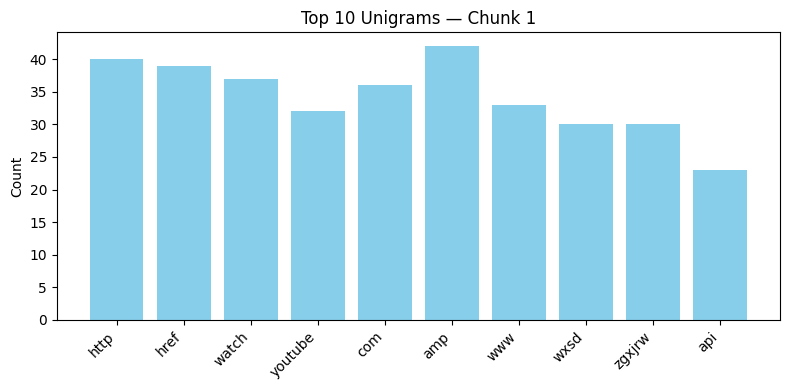

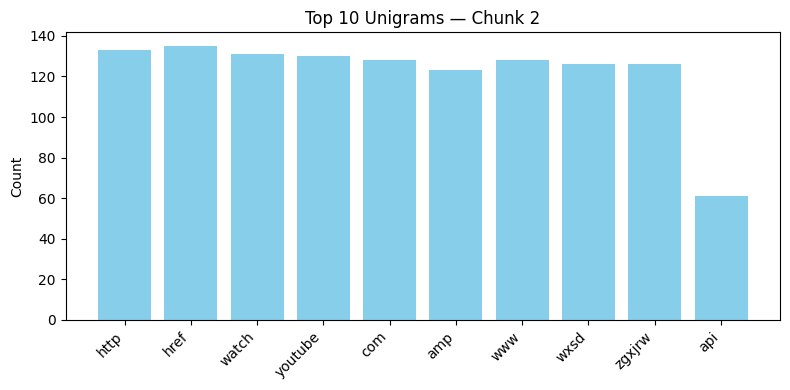

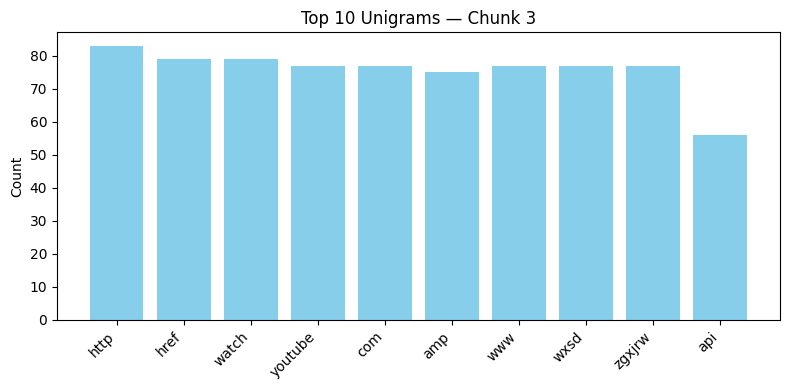

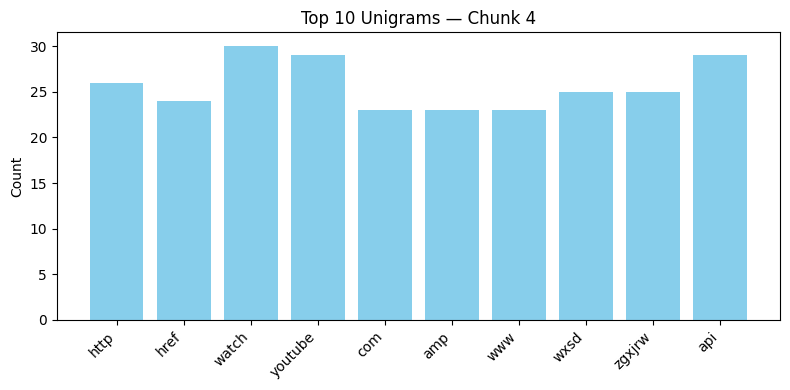

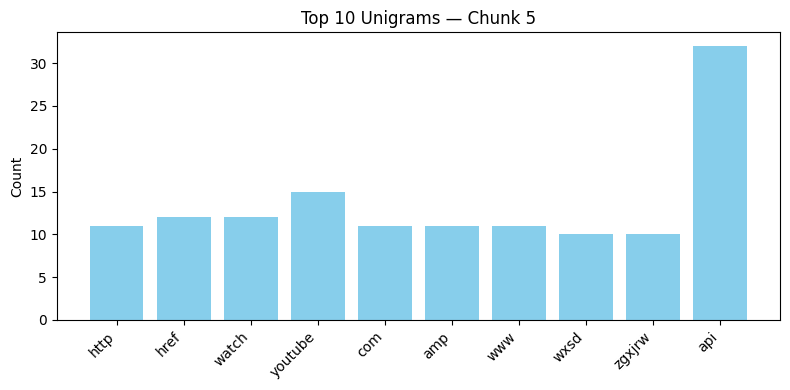

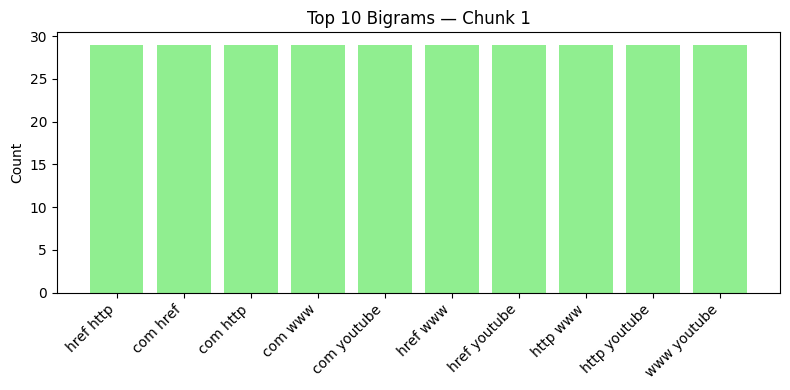

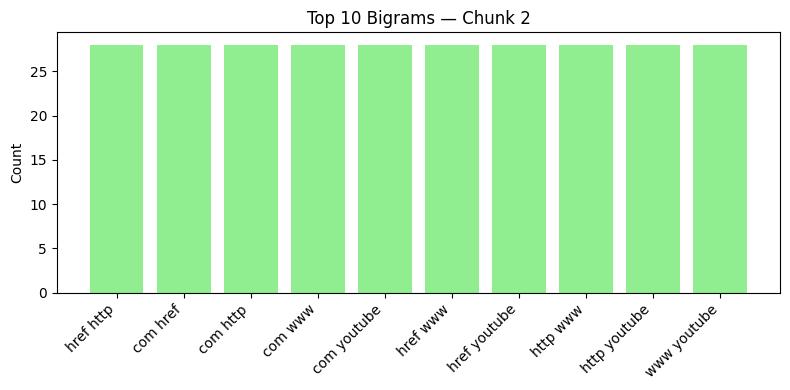

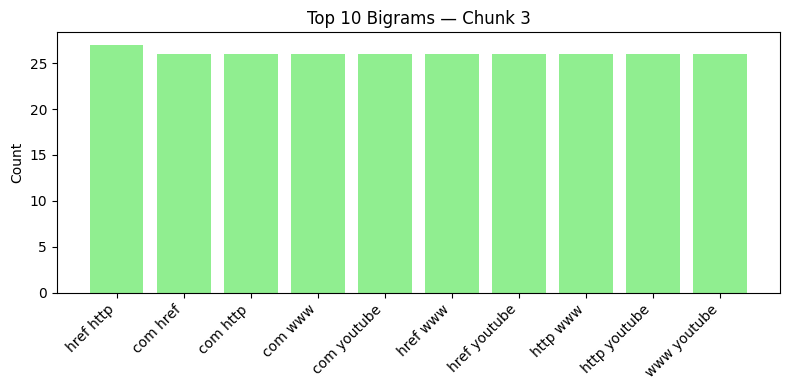

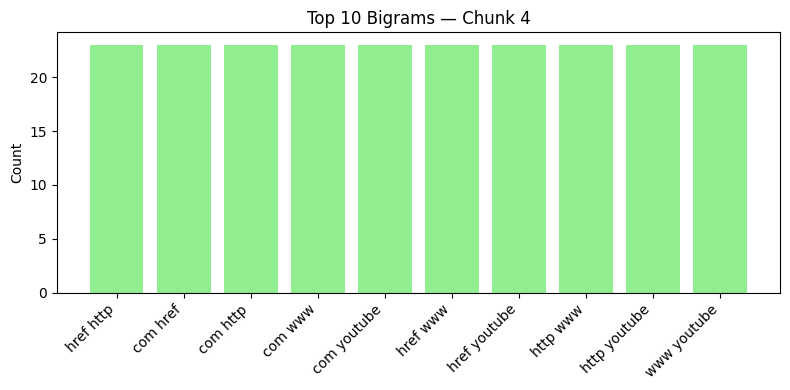

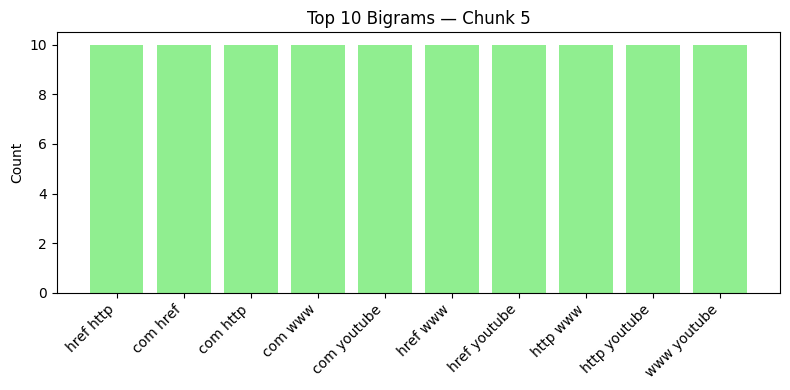

In [6]:
# Plot Unigram Bar Charts
for i in range(5):
    counts = [uni_counts[i].get(w, 0) for w in top10_uni_terms]
    plt.figure(figsize=(8, 4))
    plt.bar(top10_uni_terms, counts, color="skyblue")
    plt.title(f"Top 10 Unigrams — Chunk {i+1}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Plot Bigram Bar Charts
bi_labels = [f"{p[0]} {p[1]}" for p in top10_bi_pairs]
for i in range(5):
    counts = [bi_counts[i].get(p, 0) for p in top10_bi_pairs]
    plt.figure(figsize=(8, 4))
    plt.bar(bi_labels, counts, color="lightgreen")
    plt.title(f"Top 10 Bigrams — Chunk {i+1}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [7]:
# UNIGRAM tracking table
uni_table = pd.DataFrame({
    "Pattern": top10_uni_terms,
    "Chunk 1": [uni_counts[0].get(w, 0) for w in top10_uni_terms],
    "Chunk 2": [uni_counts[1].get(w, 0) for w in top10_uni_terms],
    "Chunk 3": [uni_counts[2].get(w, 0) for w in top10_uni_terms],
    "Chunk 4": [uni_counts[3].get(w, 0) for w in top10_uni_terms],
    "Chunk 5": [uni_counts[4].get(w, 0) for w in top10_uni_terms],
})

print("UNIGRAM Tracking Table (Top 10):")
display(uni_table)

# BIGRAM tracking table
bi_table = pd.DataFrame({
    "Pattern": [f"({p[0]}, {p[1]})" for p in top10_bi_pairs],
    "Chunk 1": [bi_counts[0].get(p, 0) for p in top10_bi_pairs],
    "Chunk 2": [bi_counts[1].get(p, 0) for p in top10_bi_pairs],
    "Chunk 3": [bi_counts[2].get(p, 0) for p in top10_bi_pairs],
    "Chunk 4": [bi_counts[3].get(p, 0) for p in top10_bi_pairs],
    "Chunk 5": [bi_counts[4].get(p, 0) for p in top10_bi_pairs],
})

print("BIGRAM Tracking Table (Top 10):")
display(bi_table)

UNIGRAM Tracking Table (Top 10):


,Pattern,Chunk 1,Chunk 2,Chunk 3,Chunk 4,Chunk 5
0,http,40,133,83,26,11
1,href,39,135,79,24,12
2,watch,37,131,79,30,12
3,youtube,32,130,77,29,15
4,com,36,128,77,23,11
5,amp,42,123,75,23,11
6,www,33,128,77,23,11
7,wxsd,30,126,77,25,10
8,zgxjrw,30,126,77,25,10
9,api,23,61,56,29,32


BIGRAM Tracking Table (Top 10):


,Pattern,Chunk 1,Chunk 2,Chunk 3,Chunk 4,Chunk 5
0,"(href, http)",29,28,27,23,10
1,"(com, href)",29,28,26,23,10
2,"(com, http)",29,28,26,23,10
3,"(com, www)",29,28,26,23,10
4,"(com, youtube)",29,28,26,23,10
5,"(href, www)",29,28,26,23,10
6,"(href, youtube)",29,28,26,23,10
7,"(http, www)",29,28,26,23,10
8,"(http, youtube)",29,28,26,23,10
9,"(www, youtube)",29,28,26,23,10


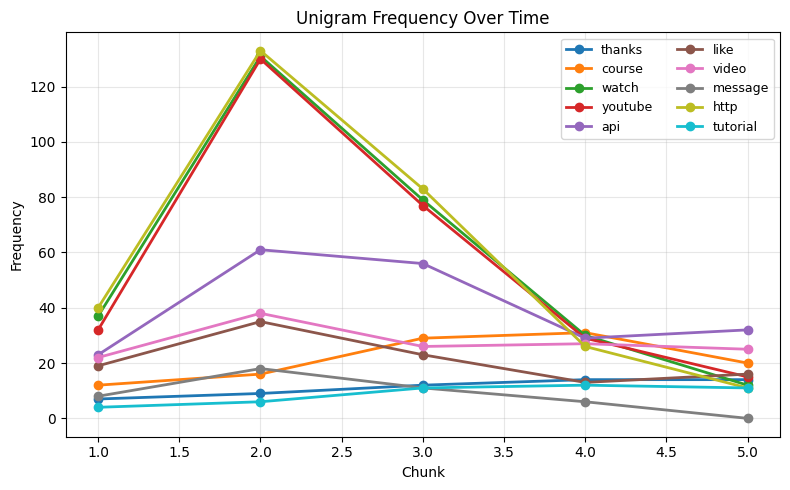

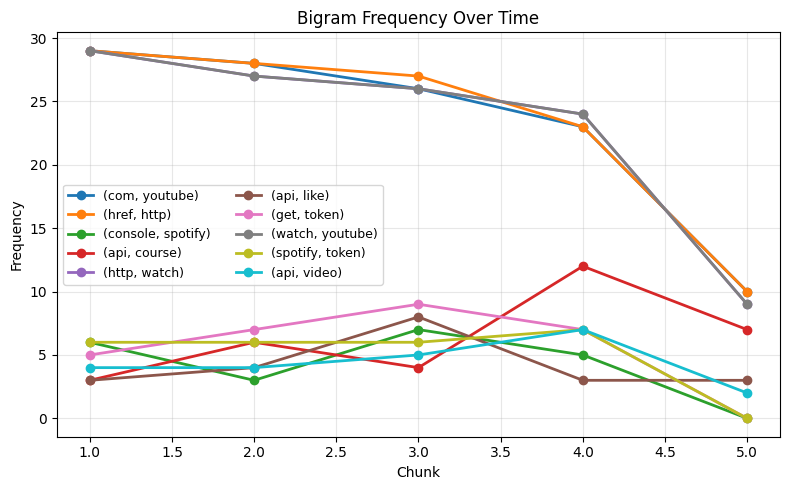

In [8]:
# Selected unigrams and bigrams
selected_unigrams = ["thanks","course","watch","youtube","api","like","video","message","http","tutorial"]
selected_bigrams  = ["(com, youtube)", "(href, http)", "(console, spotify)", "(api, course)",
                     "(http, watch)", "(api, like)", "(get, token)", "(watch, youtube)",
                     "(spotify, token)", "(api, video)"]

# Get unigram counts for each chunk
def unigram_series(token):
    return [uni_counts[i].get(token, 0) for i in range(5)]

# Convert bigram string to tuple
def parse_bigram_label(label):
    m = re.match(r"\(\s*([^,]+)\s*,\s*([^)]+)\s*\)", label)
    if not m:
        raise ValueError(f"Bad bigram label: {label}")
    a, b = m.group(1).strip(), m.group(2).strip()
    return tuple(sorted([a, b]))

# Get bigram counts for each chunk
def bigram_series(label):
    pair = parse_bigram_label(label)
    return [bi_counts[i].get(pair, 0) for i in range(5)]

# Create frequency tables
uni_freq_df = pd.DataFrame({u: unigram_series(u) for u in selected_unigrams}, index=[1,2,3,4,5])
uni_freq_df.index.name = "Chunk"

bi_freq_df = pd.DataFrame({b: bigram_series(b) for b in selected_bigrams}, index=[1,2,3,4,5])
bi_freq_df.index.name = "Chunk"

# Plot Unigrams
plt.figure(figsize=(8,5))
for col in uni_freq_df.columns:
    plt.plot(uni_freq_df.index, uni_freq_df[col], marker='o', markersize=6, linewidth=2, label=col)
plt.xlabel("Chunk")
plt.ylabel("Frequency")
plt.title("Unigram Frequency Over Time")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Plot Bigrams
plt.figure(figsize=(8,5))
for col in bi_freq_df.columns:
    plt.plot(bi_freq_df.index, bi_freq_df[col], marker='o', markersize=6, linewidth=2, label=col)
plt.xlabel("Chunk")
plt.ylabel("Frequency")
plt.title("Bigram Frequency Over Time")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


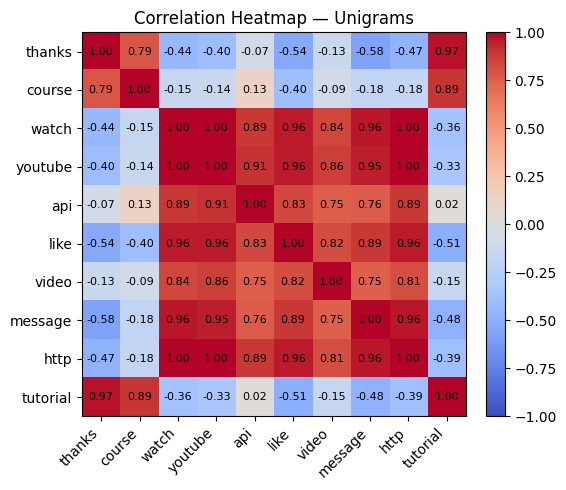

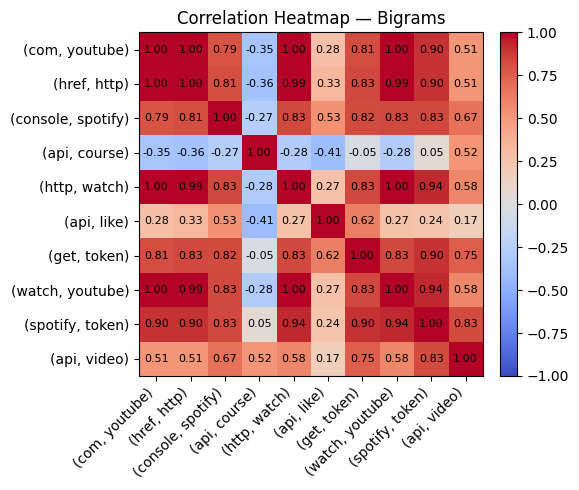

In [9]:
# Compute correlation matrices
corr_uni = uni_freq_df.corr()
corr_bi  = bi_freq_df.corr()

# Unigram Heatmap
plt.figure(figsize=(6,5))
im = plt.imshow(corr_uni, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Correlation Heatmap — Unigrams")
plt.xticks(range(len(corr_uni.columns)), corr_uni.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_uni.index)), corr_uni.index)
for i in range(len(corr_uni)):
    for j in range(len(corr_uni)):
        plt.text(j, i, f"{corr_uni.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

# Bigram Heatmap
plt.figure(figsize=(6,5))
im = plt.imshow(corr_bi, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Correlation Heatmap — Bigrams")
plt.xticks(range(len(corr_bi.columns)), corr_bi.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_bi.index)), corr_bi.index)
for i in range(len(corr_bi)):
    for j in range(len(corr_bi)):
        plt.text(j, i, f"{corr_bi.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()